In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.0001, n_iters=100):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0.0  # Bias / intercept
        self.theta_1 = 0.0  # Weight / slope
        self.cost_history = []

    def fit(self, X, y):
        self.cost_history = []
        for _ in range(self.n_iters):
            # 1. Hypothesis: y_hat = theta_0 + theta_1 * X
            y_pred = self.theta_0 + self.theta_1 * X
            
            # 2. Residual error
            errors = y_pred - y
            
            # 3. Cost function: SSE = 0.5 * sum(errors^2)
            sse = 0.5 * np.sum(errors ** 2)
            self.cost_history.append(sse)
            
            # 4. Gradients of SSE
            d_theta_0 = np.sum(errors)
            d_theta_1 = np.sum(errors * X)
            
            # 5. Parameter update step
            self.theta_0 -= self.learning_rate * d_theta_0
            self.theta_1 -= self.learning_rate * d_theta_1
        return self

    def predict(self, X):
        return self.theta_0 + self.theta_1 * X

    def plot_training(self, X, y):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        # Plot SSE vs Iterations
        ax1.plot(range(1, len(self.cost_history) + 1), self.cost_history, 'b-o', markersize=3)
        ax1.set_title("SSE over Iterations")
        ax1.set_xlabel("Iteration")
        ax1.set_ylabel("SSE")
        ax1.grid(True)
        
        # Plot regression line and actual points
        ax2.scatter(X, y, color='blue', label='Data Points')
        line_x = np.linspace(min(X) - 5, max(X) + 5, 100)
        line_y = self.predict(line_x)
        ax2.plot(line_x, line_y, color='red', label='Regression Line')
        ax2.set_title("Fitted Line vs Data Points")
        ax2.set_xlabel("X (House Size in m²)")
        ax2.set_ylabel("y (Price in thousands)")
        ax2.legend()
        ax2.grid(True)
        
        plt.tight_layout()
        plt.show()

In [5]:
# Raw data defined by the instructor
X = np.array([50, 60, 70, 80, 90], dtype=float)
y = np.array([150, 180, 210, 240, 270], dtype=float)

print("Feature X:", X)
print("Target y: ", y)

Feature X: [50. 60. 70. 80. 90.]
Target y:  [150. 180. 210. 240. 270.]


In [18]:
# Initialize and fit model
model = LinearRegressionGD(learning_rate=0.00001, n_iters=100)
model.fit(X, y)

print(f"Learned theta_0 (Intercept): {model.theta_0:.4f}")
print(f"Learned theta_1 (Slope):     {model.theta_1:.4f}")

Learned theta_0 (Intercept): 0.0412
Learned theta_1 (Slope):     2.9994


In [19]:
pred_70 = model.predict(np.array([70.0]))
print(f"Predicted price for 70 m² house: {pred_70[0]:.2f} thousand")

Predicted price for 70 m² house: 210.00 thousand


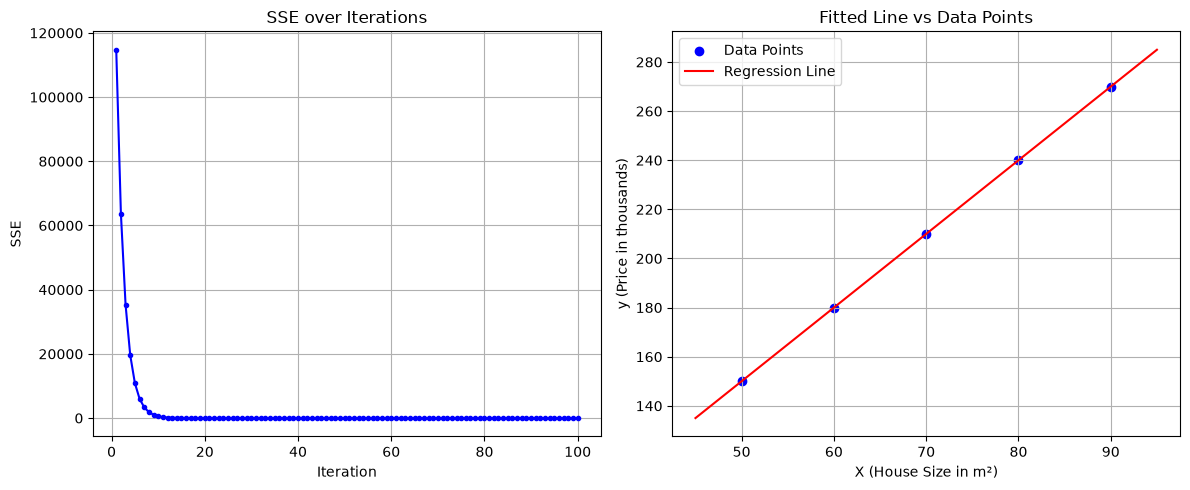

In [23]:
model.plot_training(X, y)

In [21]:
# 1. Very small learning rate
model_small = LinearRegressionGD(learning_rate=1e-6, n_iters=100)
model_small.fit(X, y)

# 2. Large learning rate (causes overshooting/divergence)
model_large = LinearRegressionGD(learning_rate=0.001, n_iters=10)
model_large.fit(X, y)

print(f"Final SSE (Small LR = 1e-6): {model_small.cost_history[-1]:.4f}")
print(f"Final SSE (Large LR = 1e-3): {model_large.cost_history[-1]:.4e}")

Final SSE (Small LR = 1e-6): 688.8646
Final SSE (Large LR = 1e-3): 1.1649e+30


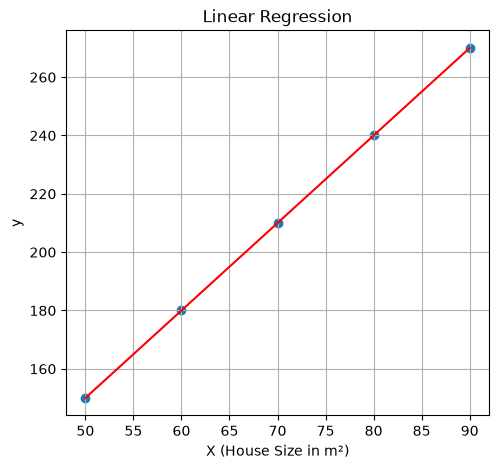

In [22]:
plt.figure(figsize =(12,5))
plt.subplot(1,2,1)
plt.scatter(X,y)
plt.plot(X, model.theta_1*X + model.theta_0, color = 'red')
plt.title("Linear Regression")
plt.xlabel("X (House Size in m²)")
plt.ylabel("y") 
plt.grid()


